In [1]:
import random
import datetime

import numpy as np

import qutip as qt

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors

from IPython.display import HTML
from matplotlib import animation

%load_ext autoreload
%autoreload 2

from utils import *

plt.rcParams["font.family"] = "serif"  # 'sans-serif', 'monospace', etc.
plt.rcParams["font.serif"] = ["Times New Roman"]  # Specific serif font
plt.rcParams["font.size"] = 14  # Global font size
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{braket}"

In [227]:
N = 80
delta = 0.3
cutoff = 10
alpha = np.sqrt(np.pi / 2)
beta = np.sqrt(np.pi / 2) * 1j

vac = qt.basis(N, 0)

gkp_0, gkp_1 = generate_gkp_state(N, alpha, beta, delta, cutoff)
even_cat, odd_cat = generate_cat_state(N, alpha)

input_squeezing = -10 * np.log10(delta**2)
print(f"Input Squeezing: {input_squeezing}")

Input Squeezing: 10.457574905606752


In [263]:
K = 0.1

a_dag = qt.create(N)
a = qt.destroy(N)

amp = 0.1

# args = {'A': 1.0, 't0': 5.0, 'sigma': 1.0}
args = {"x0": 5.0}

wc = K * 4
print(wc)

tlist = np.linspace(0, 20, 500)


def sigmoid(x, args):
    x0 = args.get("x0", 0.0)
    k = args.get("k", 0.5)
    return 1 / (1 + np.exp(-k * (x - x0)))


def gaussian(t, args):
    A = args.get("A", 1.0)
    t0 = args.get("t0", 5.0)
    sigma = args.get("sigma", 1.0)
    return A * np.exp(-((t - t0) ** 2) / (2 * sigma**2))


def tpd(t, args):
    return sigmoid(t, args) * np.exp(1j * wc * t)


def tpd_c(t, args):
    return sigmoid(t, args) * np.exp(-1j * wc * t)


H_kerr = K * (a_dag**2 * a**2)
H = [H_kerr, [a_dag**2, tpd], [a**2, tpd_c]]

0.4


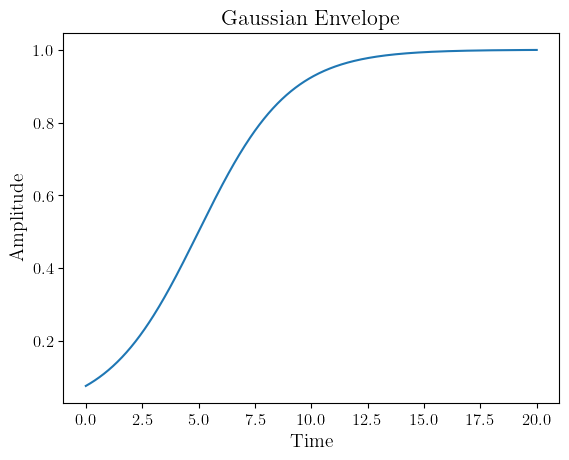

In [264]:
envelope = [sigmoid(t, args) for t in tlist]
plt.plot(tlist, envelope)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Gaussian Envelope")
plt.show()

In [265]:
result = qt.mesolve(H, vac, tlist, [], [], args=args)

In [266]:
import cmath

initial_state = vac
final_state = even_cat

psi_f_perp = (final_state - initial_state.overlap(final_state) * initial_state).unit()
phi = cmath.phase(initial_state.overlap(final_state))
burel_angle = np.arccos(np.abs(initial_state.overlap(final_state)))

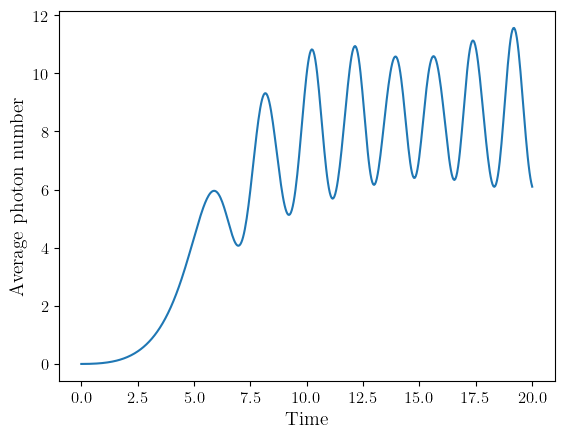

In [268]:
# -------------------------
# Extract populations
# -------------------------
populations = [qt.expect(a.dag() * a, state) for state in result.states]

plt.plot(tlist, populations)
plt.xlabel("Time")
plt.ylabel("Average photon number")
plt.show()

In [269]:
# Preallocate array
P_n_t = np.zeros((N, len(tlist)))

for idx, rho_t in enumerate(result.states):
    P_n_t[:, idx] = np.abs(rho_t.full().flatten())

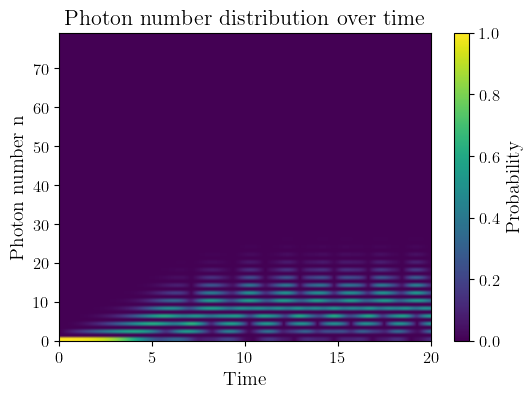

In [270]:
plt.figure(figsize=(6, 4))
plt.imshow(
    P_n_t, extent=[tlist[0], tlist[-1], 0, N - 1], aspect="auto", origin="lower", cmap="viridis"
)
plt.colorbar(label="Probability")
plt.xlabel("Time")
plt.ylabel("Photon number n")
plt.title("Photon number distribution over time")
plt.show()

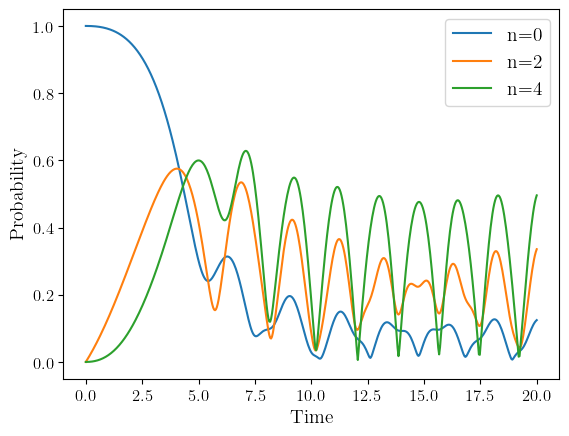

In [271]:
plt.plot(tlist, P_n_t[0, :], label="n=0")
plt.plot(tlist, P_n_t[2, :], label="n=2")
plt.plot(tlist, P_n_t[4, :], label="n=4")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [281]:
# Sample parameters
N = 1024  # number of points
T = 0.01  # sampling interval (seconds)

args = {"A": 1.0, "t0": 5.0, "sigma": 1.0}

# Time array
t = np.linspace(0, N * T, N, endpoint=False)
f = 5
y = np.sin(2 * np.pi * f * t)
Y = np.fft.fft(y)  # FFT of y
freq = np.fft.fftfreq(N, T)  # frequency axis

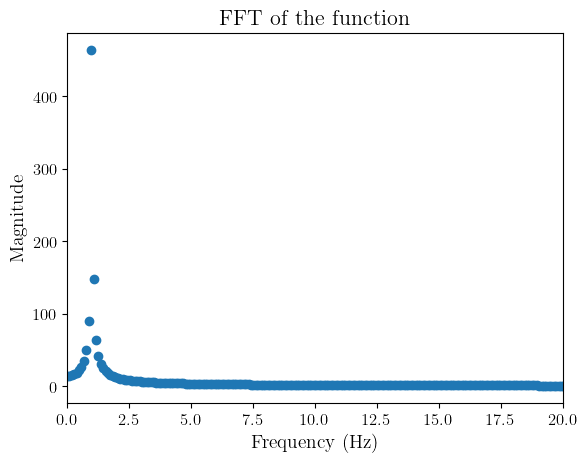

In [283]:
plt.scatter(freq, np.abs(Y))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of the function")
plt.xlim(0, 20)  # optional: show positive frequencies only
plt.show()